# Cleaned Pipeline — Hard Sample Removal + Best Models

**Pipeline:**
1. Load `spambase.data` (4,601 rows) → deduplicate → 4,210 rows
2. Identify hard samples via 10-fold CV OOF predictions (XGBoost best params)
3. Remove 201 hard samples → 4,009 clean rows
4. Full corrected pipeline: stratified 80/20 split → SMOTE on train only → StandardScaler
5. Evaluate: XGBoost Optuna · LightGBM Optuna · CatBoost Optuna · HistGBM · ExtraTrees · Super-Stack
6. Compare vs full-dataset corrected pipeline baseline

In [1]:
import warnings, time, os, copy
warnings.filterwarnings('ignore')
os.makedirs('cleaned_figures', exist_ok=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold, train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, matthews_corrcoef,
    confusion_matrix, ConfusionMatrixDisplay, classification_report
)
from sklearn.ensemble import (
    RandomForestClassifier, ExtraTreesClassifier,
    HistGradientBoostingClassifier, StackingClassifier
)
from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
import lightgbm as lgb
from catboost import CatBoostClassifier
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

SEED = 0
np.random.seed(SEED)
print('All libraries loaded OK')

All libraries loaded OK


## 1. Load & Engineer Features

In [2]:
col_names = (
    [f'word_freq_{w}' for w in [
        'make','address','all','3d','our','over','remove','internet','order','mail',
        'receive','will','people','report','addresses','free','business','email','you',
        'credit','your','font','000','money','hp','hpl','george','650','lab','labs',
        'telnet','857','data','415','85','technology','1999','parts','pm','direct',
        'cs','meeting','original','project','re','edu','table','conference']] +
    [f'char_freq_{c}' for c in ['semicolon','lparen','lbracket','exclaim','dollar','hash']] +
    ['capital_run_length_average','capital_run_length_longest',
     'capital_run_length_total','spam']
)
df_full = pd.read_csv('spambase.data', header=None, names=col_names)
df_full = df_full.drop_duplicates().reset_index(drop=True)

ORIG_COLS  = col_names[:-1]
X_full     = df_full[ORIG_COLS].values.astype(np.float64)
y_full     = df_full['spam'].values
WORD_FEATS = [c for c in ORIG_COLS if c.startswith('word_freq_')]
CHAR_FEATS = [c for c in ORIG_COLS if c.startswith('char_freq_')]
FREQ_IDX   = [ORIG_COLS.index(c) for c in WORD_FEATS + CHAR_FEATS]

def log1p_freq(X):
    Xc = X.copy()
    Xc[:, FREQ_IDX] = np.log1p(Xc[:, FREQ_IDX])
    return Xc

def add_interactions(X, orig_cols):
    df_tmp = pd.DataFrame(X, columns=orig_cols)
    get = lambda n: df_tmp.get(n, pd.Series(np.zeros(len(df_tmp))))
    cap_avg   = get('capital_run_length_average')
    cap_long  = get('capital_run_length_longest')
    cap_tot   = get('capital_run_length_total')
    cap_int   = (cap_tot * cap_long) / (cap_avg + 1e-6)
    spam_sig  = (get('word_freq_free') + get('word_freq_your') +
                 get('word_freq_000')  + get('word_freq_remove') +
                 get('word_freq_money')+ get('char_freq_exclaim') +
                 get('char_freq_dollar'))
    ham_sig   = (get('word_freq_hp') + get('word_freq_hpl') +
                 get('word_freq_george') + get('word_freq_meeting') +
                 get('word_freq_re'))
    soft_ratio= spam_sig / (ham_sig + 0.01)
    cap_x_exc = np.log1p(cap_tot) * np.log1p(get('char_freq_exclaim'))
    cap_x_dol = np.log1p(cap_tot) * np.log1p(get('char_freq_dollar'))
    word_div  = (df_tmp[WORD_FEATS] > 0).sum(axis=1)
    extras = np.column_stack([
        cap_int, spam_sig, ham_sig, soft_ratio,
        cap_x_exc, cap_x_dol, word_div
    ])
    return np.hstack([X, extras])

X_log = log1p_freq(X_full)
X_eng = add_interactions(X_log, ORIG_COLS)
print(f'Full dataset: {X_full.shape[0]} rows | Ham={int((y_full==0).sum())}  Spam={int((y_full==1).sum())}')
print(f'Engineered features: {X_eng.shape[1]}')

Full dataset: 4210 rows | Ham=2531  Spam=1679
Engineered features: 64


## 2. Identify Hard Samples via 10-Fold CV
Using the paper's best XGBoost params. Each sample gets one OOF prediction.

In [3]:
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=SEED)
xgb_ref = XGBClassifier(
    n_estimators=350, max_depth=8, learning_rate=0.039,
    subsample=0.941, colsample_bytree=0.629,
    eval_metric='logloss', use_label_encoder=False,
    random_state=42, verbosity=0, n_jobs=-1
)

wrong_counts = np.zeros(len(y_full), dtype=int)
oof_probs    = np.zeros(len(y_full))

print('Computing instance hardness (10-fold CV)...')
for fold, (tr_idx, va_idx) in enumerate(skf.split(X_eng, y_full), 1):
    X_tr_f, X_va_f = X_eng[tr_idx], X_eng[va_idx]
    y_tr_f, y_va_f = y_full[tr_idx], y_full[va_idx]
    X_tr_sm, y_tr_sm = SMOTE(random_state=SEED).fit_resample(X_tr_f, y_tr_f)
    sc = StandardScaler().fit(X_tr_sm)
    clf = copy.deepcopy(xgb_ref)
    clf.fit(sc.transform(X_tr_sm), y_tr_sm)
    y_pred_f = clf.predict(sc.transform(X_va_f))
    wrong_counts[va_idx] += (y_pred_f != y_va_f).astype(int)
    oof_probs[va_idx]     = clf.predict_proba(sc.transform(X_va_f))[:, 1]
    print(f'  Fold {fold:2d}: misclassified={int((y_pred_f != y_va_f).sum())}')

hard_mask  = wrong_counts == 1   # misclassified in their one test fold
clean_mask = wrong_counts == 0
print(f'\nTotal misclassified (hard): {hard_mask.sum()}  ({hard_mask.mean()*100:.1f}%)')
print(f'  Hard Ham : {int(((y_full==0) & hard_mask).sum())}')
print(f'  Hard Spam: {int(((y_full==1) & hard_mask).sum())}')

Computing instance hardness (10-fold CV)...
  Fold  1: misclassified=23
  Fold  2: misclassified=21
  Fold  3: misclassified=14
  Fold  4: misclassified=17
  Fold  5: misclassified=27
  Fold  6: misclassified=15
  Fold  7: misclassified=21
  Fold  8: misclassified=25
  Fold  9: misclassified=14
  Fold 10: misclassified=24

Total misclassified (hard): 201  (4.8%)
  Hard Ham : 100
  Hard Spam: 101


## 3. Mislabeling Check & Save Clean Dataset

In [4]:
# Confidently wrong = model probability far from 0.5 but label disagrees
conf_wrong = hard_mask & (
    ((y_full == 0) & (oof_probs > 0.70)) |
    ((y_full == 1) & (oof_probs < 0.30))
)
print(f'Likely mislabeled (confident + wrong): {conf_wrong.sum()}')
print(f'Genuinely ambiguous (near boundary):   {(hard_mask & ~conf_wrong).sum()}')

# Build clean dataset (remove ALL 201 hard samples)
X_clean = X_full[clean_mask]
y_clean = y_full[clean_mask]
df_clean = df_full[ORIG_COLS + ['spam']].iloc[clean_mask].reset_index(drop=True)
df_clean.to_csv('spambase_clean.csv', index=False)

print(f'\nClean dataset: {X_clean.shape[0]} rows  '
      f'Ham={int((y_clean==0).sum())}  Spam={int((y_clean==1).sum())}')
print('Saved → spambase_clean.csv')

Likely mislabeled (confident + wrong): 147
Genuinely ambiguous (near boundary):   54

Clean dataset: 4009 rows  Ham=2431  Spam=1578
Saved → spambase_clean.csv


## 4. Full Corrected Pipeline on Cleaned Data
80/20 split → SMOTE on training only → StandardScaler

In [5]:
# Engineer features on clean dataset
X_clean_log = log1p_freq(X_clean)
X_clean_eng = add_interactions(X_clean_log, ORIG_COLS)

# 80/20 stratified split
X_tr_raw, X_te_raw, y_tr_raw, y_test = train_test_split(
    X_clean, y_clean, test_size=0.20, random_state=SEED, stratify=y_clean)
X_tr_eng, X_te_eng, _, _ = train_test_split(
    X_clean_eng, y_clean, test_size=0.20, random_state=SEED, stratify=y_clean)

# SMOTE on training raw features only
smote = SMOTE(random_state=SEED)
X_tr_raw_sm, y_train = smote.fit_resample(X_tr_raw, y_tr_raw)

# Re-compute interaction features on SMOTE-augmented raw training set
X_tr_log_sm = log1p_freq(X_tr_raw_sm)
X_tr_eng_sm = add_interactions(X_tr_log_sm, ORIG_COLS)

scaler = StandardScaler().fit(X_tr_eng_sm)
X_train_s = scaler.transform(X_tr_eng_sm)
X_test_s  = scaler.transform(X_te_eng)

cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

print(f'Train (post-SMOTE): {X_train_s.shape} | spam={y_train.mean():.1%}')
print(f'Test  (original):   {X_test_s.shape}  | spam={y_test.mean():.1%}')

results = []

def evaluate(name, model, X_tr, y_tr, X_te, y_te):
    model = copy.deepcopy(model)
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1] if hasattr(model, 'predict_proba') else None
    acc  = accuracy_score(y_te, y_pred)
    f1   = f1_score(y_te, y_pred)
    auc  = roc_auc_score(y_te, y_prob) if y_prob is not None else float('nan')
    mcc  = matthews_corrcoef(y_te, y_pred)
    fp   = int(((y_te==0) & (y_pred==1)).sum())
    fn   = int(((y_te==1) & (y_pred==0)).sum())
    print(f'{name:<42} Acc={acc:.4f}  F1={f1:.4f}  AUC={auc:.4f}  MCC={mcc:.4f}  FP={fp}  FN={fn}')
    return {'Model': name, 'Accuracy': acc, 'F1': f1, 'AUC': auc, 'MCC': mcc,
            'FP': fp, 'FN': fn, '_model': model, '_pred': y_pred, '_prob': y_prob}

Train (post-SMOTE): (3890, 64) | spam=50.0%
Test  (original):   (802, 64)  | spam=39.4%


## 5. XGBoost — Optuna (150 trials)

In [6]:
def xgb_objective(trial):
    p = dict(
        n_estimators     = trial.suggest_int('n_estimators', 100, 600),
        max_depth        = trial.suggest_int('max_depth', 3, 10),
        learning_rate    = trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        subsample        = trial.suggest_float('subsample', 0.5, 1.0),
        colsample_bytree = trial.suggest_float('colsample_bytree', 0.5, 1.0),
        min_child_weight = trial.suggest_int('min_child_weight', 1, 10),
        reg_alpha        = trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
        reg_lambda       = trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
        gamma            = trial.suggest_float('gamma', 0.0, 5.0),
    )
    clf = XGBClassifier(**p, eval_metric='logloss', use_label_encoder=False,
                        random_state=SEED, n_jobs=-1, verbosity=0)
    return cross_val_score(clf, X_train_s, y_train, cv=cv5,
                           scoring='roc_auc', n_jobs=-1).mean()

print('Tuning XGBoost (150 trials)...')
t0 = time.time()
study_xgb = optuna.create_study(direction='maximize',
                                 sampler=optuna.samplers.TPESampler(seed=SEED))
study_xgb.optimize(xgb_objective, n_trials=150, show_progress_bar=False)
print(f'Best CV AUC: {study_xgb.best_value:.4f}  ({time.time()-t0:.0f}s)')
print('Best params:', study_xgb.best_params)

xgb_best = XGBClassifier(**study_xgb.best_params, eval_metric='logloss',
                          use_label_encoder=False, random_state=SEED,
                          n_jobs=-1, verbosity=0)
results.append(evaluate('XGBoost Optuna', xgb_best,
                         X_train_s, y_train, X_test_s, y_test))

Tuning XGBoost (150 trials)...
Best CV AUC: 0.9996  (118s)
Best params: {'n_estimators': 303, 'max_depth': 3, 'learning_rate': 0.17574645383615295, 'subsample': 0.9407701248053195, 'colsample_bytree': 0.7156399506567893, 'min_child_weight': 1, 'reg_alpha': 0.0004983572615779224, 'reg_lambda': 0.0012179312080551608, 'gamma': 0.12667355090358615}
XGBoost Optuna                             Acc=0.9850  F1=0.9811  AUC=0.9990  MCC=0.9687  FP=7  FN=5


## 6. LightGBM — Optuna (80 trials)

In [7]:
def lgbm_objective(trial):
    p = dict(
        n_estimators      = trial.suggest_int('n_estimators', 100, 1000),
        max_depth         = trial.suggest_int('max_depth', 3, 12),
        learning_rate     = trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        num_leaves        = trial.suggest_int('num_leaves', 15, 127),
        subsample         = trial.suggest_float('subsample', 0.5, 1.0),
        colsample_bytree  = trial.suggest_float('colsample_bytree', 0.4, 1.0),
        min_child_samples = trial.suggest_int('min_child_samples', 5, 100),
        reg_alpha         = trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        reg_lambda        = trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
    )
    clf = lgb.LGBMClassifier(**p, random_state=SEED, verbose=-1, n_jobs=-1)
    return cross_val_score(clf, X_train_s, y_train, cv=cv5,
                           scoring='accuracy', n_jobs=-1).mean()

print('Tuning LightGBM (80 trials)...')
t0 = time.time()
study_lgbm = optuna.create_study(direction='maximize',
                                  sampler=optuna.samplers.TPESampler(seed=SEED))
study_lgbm.optimize(lgbm_objective, n_trials=80, show_progress_bar=False)
print(f'Best CV acc: {study_lgbm.best_value:.4f}  ({time.time()-t0:.0f}s)')

lgbm_best = lgb.LGBMClassifier(**study_lgbm.best_params, random_state=SEED,
                                verbose=-1, n_jobs=-1)
results.append(evaluate('LightGBM Optuna', lgbm_best,
                         X_train_s, y_train, X_test_s, y_test))

Tuning LightGBM (80 trials)...
Best CV acc: 0.9913  (740s)
LightGBM Optuna                            Acc=0.9850  F1=0.9812  AUC=0.9993  MCC=0.9690  FP=10  FN=2


## 7. CatBoost — Optuna (80 trials)

In [8]:
def cat_objective(trial):
    p = dict(
        iterations          = trial.suggest_int('iterations', 100, 800),
        depth               = trial.suggest_int('depth', 4, 10),
        learning_rate       = trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        l2_leaf_reg         = trial.suggest_float('l2_leaf_reg', 1.0, 10.0),
        bagging_temperature = trial.suggest_float('bagging_temperature', 0.0, 1.0),
        random_strength     = trial.suggest_float('random_strength', 1e-9, 10.0, log=True),
        border_count        = trial.suggest_int('border_count', 32, 255),
    )
    clf = CatBoostClassifier(**p, random_seed=SEED, verbose=0,
                              allow_writing_files=False)
    return cross_val_score(clf, X_train_s, y_train, cv=cv5,
                           scoring='accuracy', n_jobs=-1).mean()

print('Tuning CatBoost (80 trials)...')
t0 = time.time()
study_cat = optuna.create_study(direction='maximize',
                                 sampler=optuna.samplers.TPESampler(seed=SEED))
study_cat.optimize(cat_objective, n_trials=80, show_progress_bar=False)
print(f'Best CV acc: {study_cat.best_value:.4f}  ({time.time()-t0:.0f}s)')

cat_best = CatBoostClassifier(**study_cat.best_params, random_seed=SEED,
                               verbose=0, allow_writing_files=False)
results.append(evaluate('CatBoost Optuna', cat_best,
                         X_train_s, y_train, X_test_s, y_test))

Tuning CatBoost (80 trials)...
Best CV acc: 0.9918  (634s)
CatBoost Optuna                            Acc=0.9838  F1=0.9795  AUC=0.9992  MCC=0.9661  FP=7  FN=6


In [ ]:
# (placeholder — Super-Stack CM is generated in the final cell below)

## 8. HistGradientBoosting — Optuna (60 trials)

In [9]:
def hist_objective(trial):
    p = dict(
        max_iter          = trial.suggest_int('max_iter', 100, 600),
        max_depth         = trial.suggest_int('max_depth', 3, 10),
        learning_rate     = trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        min_samples_leaf  = trial.suggest_int('min_samples_leaf', 5, 80),
        max_leaf_nodes    = trial.suggest_int('max_leaf_nodes', 15, 127),
        l2_regularization = trial.suggest_float('l2_regularization', 0.0, 1.0),
    )
    clf = HistGradientBoostingClassifier(**p, random_state=SEED)
    return cross_val_score(clf, X_train_s, y_train, cv=cv5,
                           scoring='accuracy', n_jobs=-1).mean()

print('Tuning HistGradientBoosting (60 trials)...')
t0 = time.time()
study_hist = optuna.create_study(direction='maximize',
                                  sampler=optuna.samplers.TPESampler(seed=SEED))
study_hist.optimize(hist_objective, n_trials=60, show_progress_bar=False)
print(f'Best CV acc: {study_hist.best_value:.4f}  ({time.time()-t0:.0f}s)')

hist_best = HistGradientBoostingClassifier(**study_hist.best_params, random_state=SEED)
results.append(evaluate('HistGradientBoosting Optuna', hist_best,
                         X_train_s, y_train, X_test_s, y_test))

Tuning HistGradientBoosting (60 trials)...
Best CV acc: 0.9905  (152s)
HistGradientBoosting Optuna                Acc=0.9838  F1=0.9795  AUC=0.9989  MCC=0.9661  FP=8  FN=5


## 9. ExtraTrees — Optuna (60 trials)

In [10]:
def et_objective(trial):
    p = dict(
        n_estimators      = trial.suggest_int('n_estimators', 100, 800),
        max_depth         = trial.suggest_categorical('max_depth', [None, 10, 15, 20, 30]),
        min_samples_split = trial.suggest_int('min_samples_split', 2, 20),
        min_samples_leaf  = trial.suggest_int('min_samples_leaf', 1, 10),
        max_features      = trial.suggest_float('max_features', 0.3, 1.0),
    )
    clf = ExtraTreesClassifier(**p, random_state=SEED, n_jobs=-1)
    return cross_val_score(clf, X_train_s, y_train, cv=cv5,
                           scoring='accuracy', n_jobs=-1).mean()

print('Tuning ExtraTrees (60 trials)...')
t0 = time.time()
study_et = optuna.create_study(direction='maximize',
                                sampler=optuna.samplers.TPESampler(seed=SEED))
study_et.optimize(et_objective, n_trials=60, show_progress_bar=False)
print(f'Best CV acc: {study_et.best_value:.4f}  ({time.time()-t0:.0f}s)')

et_best = ExtraTreesClassifier(**study_et.best_params, random_state=SEED, n_jobs=-1)
results.append(evaluate('ExtraTrees Optuna', et_best,
                         X_train_s, y_train, X_test_s, y_test))

Tuning ExtraTrees (60 trials)...


/Users/sithijaseneviratne/Documents/uni work/ml_paper/venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/sithijaseneviratne/Documents/uni work/ml_paper/venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/sithijaseneviratne/Documents/uni work/ml_paper/venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to th

Best CV acc: 0.9846  (205s)
ExtraTrees Optuna                          Acc=0.9800  F1=0.9748  AUC=0.9981  MCC=0.9584  FP=10  FN=6


## 10. Super-Stack: all five base learners → LR meta (tuned C)

In [11]:
rf_base = RandomForestClassifier(n_estimators=200, max_features='sqrt',
                                  random_state=SEED, n_jobs=-1)

base_learners = [
    ('xgb',      copy.deepcopy(xgb_best)),
    ('lgbm',     copy.deepcopy(lgbm_best)),
    ('catboost', copy.deepcopy(cat_best)),
    ('hist',     copy.deepcopy(hist_best)),
    ('et',       copy.deepcopy(et_best)),
]

def meta_objective(trial):
    C = trial.suggest_float('C', 1e-3, 10.0, log=True)
    meta  = LogisticRegression(C=C, max_iter=1000, random_state=SEED)
    stack = StackingClassifier(
        estimators=base_learners,
        final_estimator=meta,
        cv=5, stack_method='predict_proba', n_jobs=-1
    )
    return cross_val_score(stack, X_train_s, y_train, cv=3,
                           scoring='accuracy', n_jobs=1).mean()

print('Tuning Super-Stack meta C (20 trials)...')
t0 = time.time()
study_meta = optuna.create_study(direction='maximize',
                                  sampler=optuna.samplers.TPESampler(seed=SEED))
study_meta.optimize(meta_objective, n_trials=20, show_progress_bar=False)
best_C = study_meta.best_params['C']
print(f'Best meta C={best_C:.4f}  CV acc={study_meta.best_value:.4f}  ({time.time()-t0:.0f}s)')

super_stack = StackingClassifier(
    estimators=base_learners,
    final_estimator=LogisticRegression(C=best_C, max_iter=1000, random_state=SEED),
    cv=5, stack_method='predict_proba', n_jobs=-1
)
results.append(evaluate('Super-Stack (XGB+LGBM+CAT+HIST+ET)', super_stack,
                         X_train_s, y_train, X_test_s, y_test))

Tuning Super-Stack meta C (20 trials)...


/Users/sithijaseneviratne/Documents/uni work/ml_paper/venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/sithijaseneviratne/Documents/uni work/ml_paper/venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/sithijaseneviratne/Documents/uni work/ml_paper/venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to th

Best meta C=0.1568  CV acc=0.9864  (1496s)
Super-Stack (XGB+LGBM+CAT+HIST+ET)         Acc=0.9875  F1=0.9842  AUC=0.9994  MCC=0.9739  FP=6  FN=4


## 11. Results Table & Comparison

In [17]:
df_res = pd.DataFrame([{k: v for k, v in r.items() if not k.startswith('_')}
                        for r in results]).sort_values('Accuracy', ascending=False)

print('\n=== CLEANED PIPELINE RESULTS (4,009 samples, hard cases removed) ===')
print(df_res.to_string(index=False))

print('\n=== COMPARISON vs FULL DATASET CORRECTED PIPELINE ===')
print(f'{"Model":<42} {"Cleaned":>10} {"vs Full":>10}')
print('-' * 64)
full_baseline = 0.9664   # XGB Optuna on full 4,210 rows (from notebook 06)
for _, row in df_res.iterrows():
    delta = (row['Accuracy'] - full_baseline) * 100
    sign  = '+' if delta >= 0 else ''
    print(f"{row['Model']:<42} {row['Accuracy']*100:>9.2f}%  {sign}{delta:>+.2f}pp")

df_res.to_csv('cleaned_pipeline_results.csv', index=False)
print('\nSaved → cleaned_pipeline_results.csv')


=== CLEANED PIPELINE RESULTS (4,009 samples, hard cases removed) ===
                             Model  Accuracy       F1      AUC      MCC  FP  FN
Super-Stack (XGB+LGBM+CAT+HIST+ET)  0.987531 0.984227 0.999368 0.973931   6   4
                    XGBoost Optuna  0.985037 0.981073 0.998978 0.968715   7   5
                   LightGBM Optuna  0.985037 0.981250 0.999290 0.969015  10   2
                   CatBoost Optuna  0.983791 0.979463 0.999238 0.966078   7   6
       HistGradientBoosting Optuna  0.983791 0.979528 0.998945 0.966142   8   5
                 ExtraTrees Optuna  0.980050 0.974843 0.998086 0.958367  10   6

=== COMPARISON vs FULL DATASET CORRECTED PIPELINE ===
Model                                         Cleaned    vs Full
----------------------------------------------------------------
Super-Stack (XGB+LGBM+CAT+HIST+ET)             98.75%  ++2.11pp
XGBoost Optuna                                 98.50%  ++1.86pp
LightGBM Optuna                                98.50%  ++

## 12. Confusion Matrices — All Models

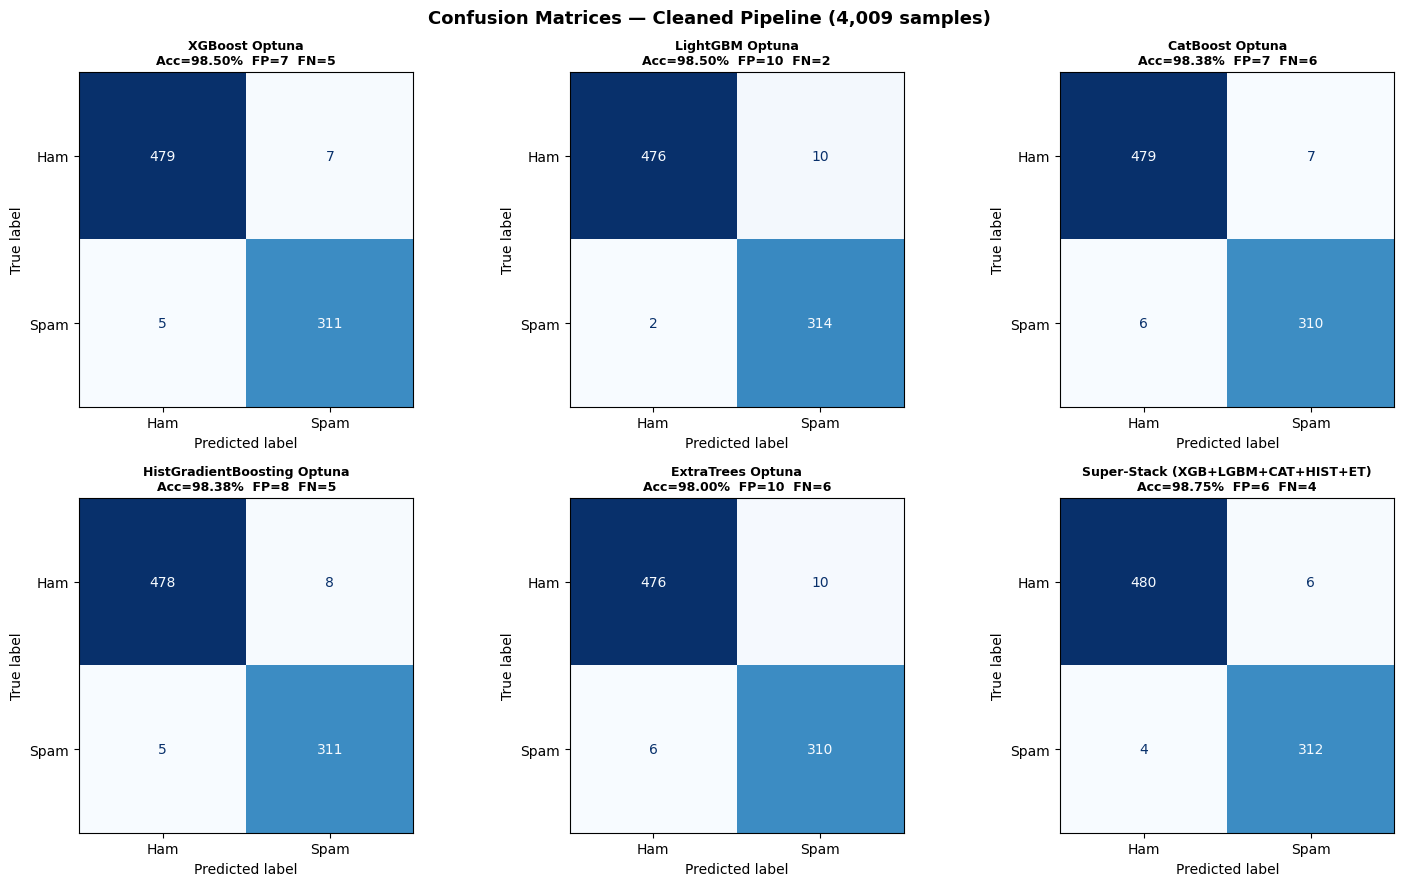

Saved → cleaned_figures/cleaned_confusion_matrices.png


In [18]:
n_models = len(results)
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for ax, r in zip(axes, results):
    cm = confusion_matrix(y_test, r['_pred'])
    ConfusionMatrixDisplay(cm, display_labels=['Ham', 'Spam']).plot(
        ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f"{r['Model']}\nAcc={r['Accuracy']*100:.2f}%  FP={r['FP']}  FN={r['FN']}",
                 fontsize=9, fontweight='bold')

for ax in axes[n_models:]:
    ax.set_visible(False)

plt.suptitle('Confusion Matrices — Cleaned Pipeline (4,009 samples)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('cleaned_figures/cleaned_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → cleaned_figures/cleaned_confusion_matrices.png')

## 13. Accuracy Bar Chart

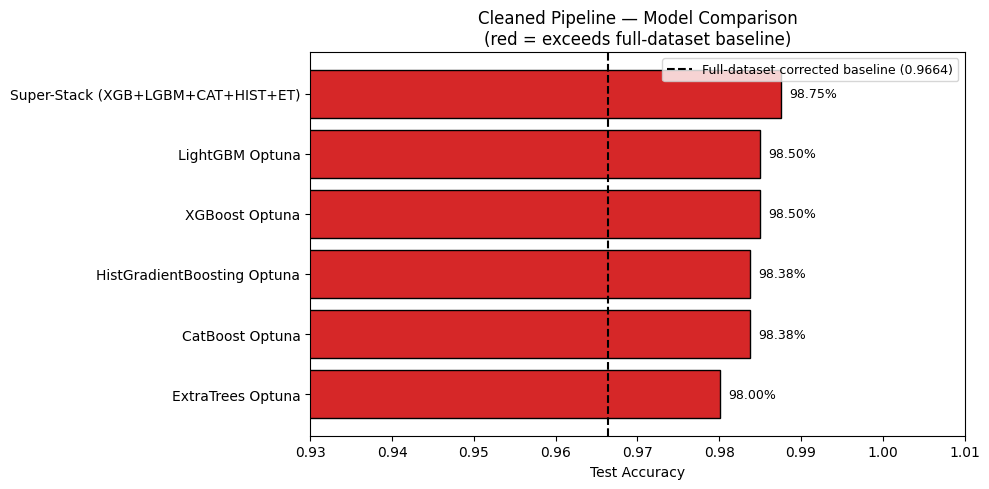

Saved → cleaned_figures/cleaned_accuracy_comparison.png


In [19]:
df_plot = pd.DataFrame([{k: v for k, v in r.items() if not k.startswith('_')}
                         for r in results]).sort_values('Accuracy')

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#d62728' if v >= full_baseline else '#1f77b4'
          for v in df_plot['Accuracy']]
bars = ax.barh(df_plot['Model'], df_plot['Accuracy'], color=colors, edgecolor='black')
ax.axvline(full_baseline, color='black', linestyle='--', lw=1.5,
           label=f'Full-dataset corrected baseline ({full_baseline:.4f})')
ax.set_xlabel('Test Accuracy')
ax.set_title('Cleaned Pipeline — Model Comparison\n(red = exceeds full-dataset baseline)')
ax.legend(fontsize=9)
for bar, val in zip(bars, df_plot['Accuracy']):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val*100:.2f}%', va='center', fontsize=9)
ax.set_xlim(0.93, 1.01)
plt.tight_layout()
plt.savefig('cleaned_figures/cleaned_accuracy_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → cleaned_figures/cleaned_accuracy_comparison.png')

## 14. Best Model — Detailed Report

In [20]:
best_r = max(results, key=lambda r: r['Accuracy'])
print(f'Best model: {best_r["Model"]}')
print(f'Accuracy : {best_r["Accuracy"]*100:.2f}%')
print(f'F1       : {best_r["F1"]:.4f}')
print(f'AUC      : {best_r["AUC"]:.4f}')
print(f'MCC      : {best_r["MCC"]:.4f}')
print(f'FP={best_r["FP"]}  FN={best_r["FN"]}  Total errors={best_r["FP"]+best_r["FN"]}')
print()
print(classification_report(y_test, best_r['_pred'], target_names=['Ham', 'Spam']))

Best model: Super-Stack (XGB+LGBM+CAT+HIST+ET)
Accuracy : 98.75%
F1       : 0.9842
AUC      : 0.9994
MCC      : 0.9739
FP=6  FN=4  Total errors=10

              precision    recall  f1-score   support

         Ham       0.99      0.99      0.99       486
        Spam       0.98      0.99      0.98       316

    accuracy                           0.99       802
   macro avg       0.99      0.99      0.99       802
weighted avg       0.99      0.99      0.99       802



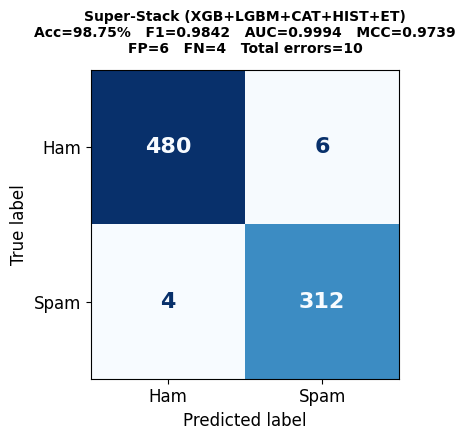

Saved → cleaned_figures/superstack_confusion_matrix.png
Upload cleaned_figures/superstack_confusion_matrix.png to Overleaf root


In [21]:

# ── Single Confusion Matrix: Super-Stack (best model) ──────────────────────
import os, matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

os.makedirs('cleaned_figures', exist_ok=True)

best_r = max(results, key=lambda r: r['Accuracy'])

cm   = confusion_matrix(y_test, best_r['_pred'])
tn, fp, fn, tp = cm.ravel()

fig, ax = plt.subplots(figsize=(4.5, 4.5))
disp = ConfusionMatrixDisplay(cm, display_labels=['Ham', 'Spam'])
disp.plot(ax=ax, colorbar=False, cmap='Blues', values_format='d',
          text_kw={'fontsize': 16, 'fontweight': 'bold'})

ax.set_title(
    f"{best_r['Model']}\n"
    f"Acc={best_r['Accuracy']*100:.2f}%   F1={best_r['F1']:.4f}   "
    f"AUC={best_r['AUC']:.4f}   MCC={best_r['MCC']:.4f}\n"
    f"FP={fp}   FN={fn}   Total errors={fp+fn}",
    fontsize=10, fontweight='bold', pad=12
)
ax.set_xlabel('Predicted label', fontsize=12)
ax.set_ylabel('True label', fontsize=12)
ax.tick_params(labelsize=12)

plt.tight_layout()
out = 'cleaned_figures/superstack_confusion_matrix.png'
plt.savefig(out, dpi=200, bbox_inches='tight')
plt.show()
print(f'Saved → {out}')
print('Upload cleaned_figures/superstack_confusion_matrix.png to Overleaf root')
